In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = {
    "Student_ID": [1,2,3,4,5,6,7,8,9,10],
    "Gender": ["Male","Female","Female","Male","Male",
               "Female","Male","Female","Male","Female"],
    "Attendance": [85, 90, np.nan, 70, 95, 88, 40, 92, 100, np.nan],
    "Math_Marks": [78, 85, 90, 35, 88, 92, 15, 95, 100, 82],
    "Science_Marks": [80, 88, 92, 30, 85, 90, 20, 96, 98, 84],
    "English_Marks": [75, 82, 88, 40, 86, 89, 25, 94, 99, 80],
    "Study_Hours": [2, 3, 4, 1, 5, 4, 0.5, 6, 8, 3]
}

df = pd.DataFrame(data)
df


,Student_ID,Gender,Attendance,Math_Marks,Science_Marks,English_Marks,Study_Hours
0,1,Male,85.0,78,80,75,2.0
1,2,Female,90.0,85,88,82,3.0
2,3,Female,NaN,90,92,88,4.0
3,4,Male,70.0,35,30,40,1.0
4,5,Male,95.0,88,85,86,5.0
5,6,Female,88.0,92,90,89,4.0
6,7,Male,40.0,15,20,25,0.5
7,8,Female,92.0,95,96,94,6.0
8,9,Male,100.0,100,98,99,8.0
9,10,Female,NaN,82,84,80,3.0


In [3]:
df.isnull().sum()


Student_ID       0
Gender           0
Attendance       2
Math_Marks       0
Science_Marks    0
English_Marks    0
Study_Hours      0
dtype: int64

In [4]:
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())


In [5]:
df.describe()


,Student_ID,Attendance,Math_Marks,Science_Marks,English_Marks,Study_Hours
count,10.00000,10.00000,10.0,10.000000,10.000000,10.000000
mean,5.50000,82.50000,76.0,76.300000,75.800000,3.650000
std,3.02765,17.02286,28.0,27.672891,24.073037,2.285826
min,1.00000,40.00000,15.0,20.000000,25.000000,0.500000
25%,3.25000,82.50000,79.0,81.000000,76.250000,2.250000
50%,5.50000,86.50000,86.5,86.500000,84.000000,3.500000
75%,7.75000,91.50000,91.5,91.500000,88.750000,4.750000
max,10.00000,100.00000,100.0,98.000000,99.000000,8.000000


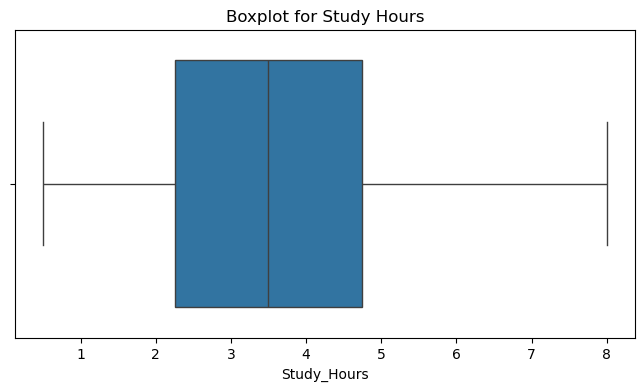

In [6]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Study_Hours"])
plt.title("Boxplot for Study Hours")
plt.show()


In [7]:
Q1 = df["Study_Hours"].quantile(0.25)
Q3 = df["Study_Hours"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df["Study_Hours"] = np.where(
    df["Study_Hours"] > upper_limit,
    upper_limit,
    np.where(df["Study_Hours"] < lower_limit, lower_limit, df["Study_Hours"])
)


In [8]:
df["Log_Study_Hours"] = np.log(df["Study_Hours"] + 1)


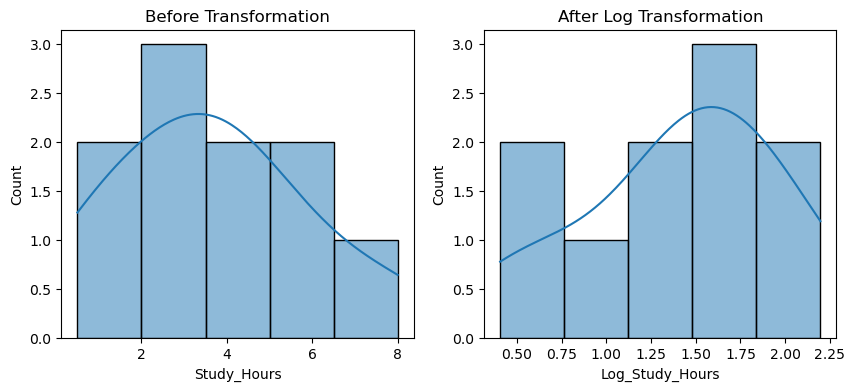

In [9]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df["Study_Hours"], kde=True)
plt.title("Before Transformation")

plt.subplot(1,2,2)
sns.histplot(df["Log_Study_Hours"], kde=True)
plt.title("After Log Transformation")

plt.show()


In [10]:
df.head()


,Student_ID,Gender,Attendance,Math_Marks,Science_Marks,English_Marks,Study_Hours,Log_Study_Hours
0,1,Male,85.0,78,80,75,2.0,1.098612
1,2,Female,90.0,85,88,82,3.0,1.386294
2,3,Female,82.5,90,92,88,4.0,1.609438
3,4,Male,70.0,35,30,40,1.0,0.693147
4,5,Male,95.0,88,85,86,5.0,1.791759
